# Galaxy Redshift Prediction with ResNet101 along with an Autoencoder

# 1. Setup

In [5]:
import os
import sys
import csv
import copy

project_root = os.path.abspath("../")
sys.path.insert(0, project_root)

%load_ext autoreload
%autoreload 2

import h5py
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from IPython.display import clear_output

import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.transforms.functional as TF
from torch.utils.data import Dataset, DataLoader
from torchvision import models
import torch.optim as optim
from torch.optim.lr_scheduler import LinearLR, CosineAnnealingLR, SequentialLR
from tqdm.notebook import tqdm

from src.data_loader import load_split, get_dataloaders, BAND_MEAN, BAND_STD
from src.metrics import redshift_metrics, evaluate_by_bin
from src.utils import *
from src.models.resnet101 import GalaxyAutoencoder, ResNet101Regressor, RedshiftLoss, FullModel

In [6]:
set_seed(42)
device = get_device()

Using MPS (Apple Metal GPU)


# 2. Data

In [26]:
BASE_DATA = os.path.abspath("../data/")
BASE_MODELS = os.path.abspath("../models/")
BASE_REPORTS = os.path.abspath("../reports/")
os.makedirs(BASE_MODELS, exist_ok=True)

TRAIN_PATH = os.path.join(BASE_DATA, "5x127x127_training_with_morphology.hdf5")
VAL_PATH = os.path.join(BASE_DATA, "5x127x127_validation_with_morphology.hdf5")
TEST_PATH = os.path.join(BASE_DATA, "5x127x127_testing_with_morphology.hdf5")

EXCLUDE = {"image", "specz_redshift", "specz_redshift_err", "specz_flag_homogeneous"}


In [8]:
df_train = load_split(TRAIN_PATH)
df_val = load_split(VAL_PATH)
df_test = load_split(TEST_PATH)

print(f"Train : {df_train.shape}")
print(f"Val   : {df_val.shape}")
print(f"Test  : {df_test.shape}")
print(f"Label range — min: {df_train['specz_redshift'].min():.4f}, "
      f"max: {df_train['specz_redshift'].max():.4f}, "
      f"mean: {df_train['specz_redshift'].mean():.4f}")

Loaded 5x127x127_training_with_morphology.hdf5: 204,573 samples, 89 features
Loaded 5x127x127_validation_with_morphology.hdf5: 40,914 samples, 89 features
Loaded 5x127x127_testing_with_morphology.hdf5: 40,914 samples, 89 features
Train : (204573, 90)
Val   : (40914, 90)
Test  : (40914, 90)
Label range — min: 0.0101, max: 3.9979, mean: 0.5950


In [9]:
with h5py.File(TRAIN_PATH, "r") as f:
    shape = f['image'].shape
    dtype = f['image'].dtype
    n_flags = f['specz_flag_homogeneous'][:].astype(bool).sum()

print(f"Full train shape: {shape}, dtype: {dtype}")
print(f"Valid galaxies after flag filter: {n_flags}")
print(f"Estimated RAM (float32): {int(n_flags) * int(np.prod(shape[1:], dtype=np.int64)) * 4 / 1e9:.2f} GB")

Full train shape: (204573, 5, 127, 127), dtype: float32
Valid galaxies after flag filter: 204573
Estimated RAM (float32): 65.99 GB


In [10]:
train_loader, val_loader, test_loader = get_dataloaders(
    train_path=TRAIN_PATH,
    val_path=VAL_PATH,
    test_path=TEST_PATH,
    batch_size=32,
    num_workers=0,
)

imgs, labels = next(iter(train_loader))
print(f"images : {imgs.shape} | dtype: {imgs.dtype} | NaN: {imgs.isnan().any().item()}")
print(f"labels : min={labels.min():.3f}  max={labels.max():.3f}  mean={labels.mean():.3f}")
print(f"per-band mean: {imgs.mean(dim=[0, 2, 3]).numpy().round(3)}")
print(f"per-band std : {imgs.std(dim=[0, 2, 3]).numpy().round(3)}")

Loaded 5x127x127_training_with_morphology.hdf5: 204,573 samples
Loaded 5x127x127_validation_with_morphology.hdf5: 40,914 samples
Loaded 5x127x127_testing_with_morphology.hdf5: 40,914 samples
images : torch.Size([32, 5, 127, 127]) | dtype: torch.float32 | NaN: False
labels : min=0.052  max=1.316  mean=0.366
per-band mean: [0.055 0.067 0.084 0.073 0.074]
per-band std : [0.795 0.979 1.305 1.178 1.108]


In [11]:
X_sample, _ = next(iter(train_loader))
print("Post-transform mean per band:", X_sample.mean(dim=[0,2,3]))
print("Post-transform std  per band:", X_sample.std(dim=[0,2,3]))

Post-transform mean per band: tensor([-0.0191, -0.0179, -0.0170, -0.0176, -0.0181])
Post-transform std  per band: tensor([0.5342, 0.5990, 0.8427, 0.7236, 0.6874])


## 3. Autoencoder Training

In [12]:
def train_autoencoder(model, loader, epochs=30, lr=1e-3):
    model = model.to(device)
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = CosineAnnealingLR(optimizer, T_max=epochs, eta_min=1e-5)
    criterion = nn.MSELoss()
    history = {"train_loss": []}

    for epoch in tqdm(range(epochs), desc="Autoencoder", unit="epoch"):
        model.train()
        total_loss, n = 0.0, 0
        for X, _ in tqdm(train_loader, leave=False, desc=f"  Epoch {epoch+1}"):
            X = X.to(device, non_blocking=True)
            recon, _ = model(X)
            loss = criterion(recon, X)
            optimizer.zero_grad(set_to_none=True)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            total_loss += loss.item() * X.shape[0]
            n += X.shape[0]

        epoch_loss = total_loss / n
        history["train_loss"].append(epoch_loss)
        scheduler.step()
        print(f"  Epoch {epoch+1}/{epochs} — Recon Loss: {epoch_loss:.5f}")

    torch.save({"model": model.state_dict()}, AE_PATH)
    print(f"Saved {AE_PATH}")
    return model, history

In [13]:
AE_PATH = os.path.join(BASE_MODELS, "resnet_autoencoder.pt")
SAVE_PATH = os.path.join(BASE_MODELS, "resnet_best.pth")
RESUME_PATH = os.path.join(BASE_MODELS, "resnet_latest.pth")

PHASE1_EPOCHS = 10
PHASE2_EPOCHS = 40
TOTAL_EPOCHS = PHASE1_EPOCHS + PHASE2_EPOCHS
patience = 15

if not os.path.exists(AE_PATH):
    _, ae_hist = train_autoencoder(
        GalaxyAutoencoder(in_channels=5, latent_dim=256), train_loader, epochs=30, lr=1e-3
    )
else:
    print("Autoencoder checkpoint found. Training already completed.")

autoencoder = GalaxyAutoencoder(in_channels=5, latent_dim=256).to(device)
ae_ckpt = torch.load(AE_PATH, map_location=device, weights_only=False)
autoencoder.load_state_dict(ae_ckpt["model"])
autoencoder.eval()
print("Autoencoder loaded ✓")

regressor = ResNet101Regressor(latent_dim=256).to(device)
full_model = FullModel(autoencoder, regressor).to(device)
criterion = RedshiftLoss(alpha=0.8)

print(f"Regressor params : {sum(p.numel() for p in regressor.parameters()):,}")
print(f"Full model params: {sum(p.numel() for p in full_model.parameters()):,}")

Autoencoder checkpoint found. Training already completed.
Autoencoder loaded ✓
Regressor params : 280,961
Full model params: 43,311,937


## 4. ResNet101 Training

In [14]:
def set_phase(model, phase):
    freeze = (phase == 1)
    for p in model.encoder_cnn.parameters():
        p.requires_grad = not freeze
    for p in model.encoder_fc.parameters():
        p.requires_grad = not freeze
    for p in model.regressor.parameters():
        p.requires_grad = True
    print("Phase 1: encoder frozen" if freeze else "Phase 2: full model unfrozen")

def make_optimizer(model, phase):
    if phase == 1:
        return optim.AdamW(model.regressor.parameters(), lr=1e-3, weight_decay=1e-4)
    return optim.AdamW([
        {"params": model.encoder_cnn.parameters(), "lr": 1e-5},
        {"params": model.encoder_fc.parameters(), "lr": 1e-4},
        {"params": model.regressor.parameters(), "lr": 5e-4},
    ], weight_decay=1e-4)

def make_scheduler(optimizer, phase, remaining_epochs):
    if phase == 1:
        warmup = LinearLR(optimizer, start_factor=0.1, end_factor=1.0, total_iters=3)
        cosine = CosineAnnealingLR(optimizer, T_max=remaining_epochs - 3, eta_min=1e-6)
        return SequentialLR(optimizer, schedulers=[warmup, cosine], milestones=[3])
    return CosineAnnealingLR(optimizer, T_max=remaining_epochs, eta_min=1e-6)

In [ ]:
def train_epoch(model, loader, optimizer, criterion, device, scaler=None, accum=2):
    model.train()
    total_loss = 0.0
    autocast_device = "cuda" if str(device) == "cuda" else "cpu"
    pbar = tqdm(loader, desc="Train", leave=True)
    optimizer.zero_grad(set_to_none=True)

    for i, (imgs, targets) in enumerate(pbar):
        imgs = imgs.to(device, non_blocking=True)
        targets = targets.to(device, non_blocking=True).reshape(-1)

        with torch.amp.autocast(autocast_device, enabled=(scaler is not None)):
            preds = model(imgs)
            loss = criterion(preds, targets) / accum

        if scaler:
            scaler.scale(loss).backward()
        else:
            loss.backward()

        if (i + 1) % accum == 0:
            if scaler:
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                scaler.step(optimizer)
                scaler.update()
            else:
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()
            optimizer.zero_grad(set_to_none=True)

        batch_loss = loss.item() * accum
        total_loss += batch_loss
        pbar.set_postfix({
            "batch_loss": f"{batch_loss:.4f}",
            "avg_loss" : f"{total_loss / (i + 1):.4f}",
            "best_val" : f"{best_loss:.4f}" if "best_loss" in globals() else "N/A",
            "lr" : f"{optimizer.param_groups[0]['lr']:.1e}",
        })

    if (i + 1) % accum != 0:
        if scaler:
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler.step(optimizer)
            scaler.update()
        else:
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
        optimizer.zero_grad(set_to_none=True)

    return total_loss / len(loader)

def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, all_preds, all_targets = 0.0, [], []

    with torch.no_grad():
        for imgs, targets in loader:
            imgs = imgs.to(device, non_blocking=True)
            targets = targets.to(device, non_blocking=True).reshape(-1)
            preds = model(imgs)
            loss = criterion(preds, targets)
            total_loss += loss.item() * imgs.size(0)
            all_preds.append(preds.cpu().float().numpy())
            all_targets.append(targets.cpu().float().numpy())

    y_pred = np.concatenate(all_preds).flatten()
    y_true = np.concatenate(all_targets).flatten()
    metrics = redshift_metrics(y_pred, y_true)
    metrics["loss"] = total_loss / len(loader.dataset)
    return metrics

In [16]:
start_epoch = 0
best_loss = float("inf")
no_improve = 0
train_losses = []
val_losses = []
current_phase = 1

set_phase(full_model, 1)
optimizer = make_optimizer(full_model, 1)
scheduler = make_scheduler(optimizer, 1, PHASE1_EPOCHS)

if os.path.exists(RESUME_PATH):
    ckpt = torch.load(RESUME_PATH, map_location=device, weights_only=False)
    full_model.load_state_dict(ckpt["model_state_dict"])
    start_epoch = ckpt.get("epoch", 0) + 1
    best_loss = ckpt.get("best_val_loss", float("inf"))
    train_losses = ckpt.get("train_losses", [])
    val_losses = ckpt.get("val_losses", [])
    no_improve = ckpt.get("no_improve", 0)
    current_phase = ckpt.get("phase", 1)
    remaining = (PHASE1_EPOCHS if current_phase == 1 else TOTAL_EPOCHS) - start_epoch
    set_phase(full_model, current_phase)
    optimizer = make_optimizer(full_model, current_phase)
    scheduler = make_scheduler(optimizer, current_phase, max(remaining, 1))
    optimizer.load_state_dict(ckpt["optimizer_state_dict"])
    scheduler.load_state_dict(ckpt["scheduler_state_dict"])
    print(f"Resumed from epoch {start_epoch}, phase {current_phase}, best val: {best_loss:.4f}")

CSV_PATH = os.path.join(BASE_MODELS, "resnet_training_metrics.csv")
if not os.path.exists(CSV_PATH):
    with open(CSV_PATH, "w", newline="") as f:
        csv.writer(f).writerow([
            "epoch", "phase", "train_loss", "val_loss", "val_mae", "val_rmse",
            "val_r2", "val_nmad", "val_outlier_pct",
            "within_0.1z", "within_0.05z", "val_bias",
            "gap", "best_val_loss", "no_improve", "is_best", "lr"
        ])

checkpoint_template = {
    "model_params" : {"latent_dim": 256, "backbone": "resnet101_ae"},
    "batch_size" : 64,
    "criterion" : "RedshiftLoss(alpha=0.8)",
    "task" : "redshift_regression",
    "torch_version" : torch.__version__,
    "mean" : BAND_MEAN.tolist() if hasattr(BAND_MEAN, "tolist") else list(BAND_MEAN),
    "std" : BAND_STD.tolist() if hasattr(BAND_STD, "tolist") else list(BAND_STD),
    "optimizer_config": {
        "phase1_regressor_lr" : 1e-3,
        "phase1_warmup_epochs" : 3,
        "phase2_encoder_cnn_lr": 1e-5,
        "phase2_encoder_fc_lr" : 1e-4,
        "phase2_regressor_lr" : 5e-4,
        "weight_decay" : 1e-4,
        "eta_min" : 1e-6,
        "phase1_epochs" : PHASE1_EPOCHS,
        "phase2_epochs" : PHASE2_EPOCHS,
        "total_epochs" : TOTAL_EPOCHS,
        "patience" : patience,
        "accum_steps" : 2,
    },
}

print(f"Training from epoch {start_epoch}/{TOTAL_EPOCHS} | Phase {current_phase}")

Phase 1: encoder frozen
Phase 2: full model unfrozen
Resumed from epoch 50, phase 2, best val: 0.1091
Training from epoch 50/50 | Phase 2


In [17]:
for epoch in range(start_epoch, TOTAL_EPOCHS):

    if epoch == PHASE1_EPOCHS and current_phase == 1:
        current_phase = 2
        set_phase(full_model, 2)
        optimizer = make_optimizer(full_model, 2)
        scheduler = make_scheduler(optimizer, 2, TOTAL_EPOCHS - epoch)
        print(f"\n{'='*50}\nSwitching to Phase 2 at epoch {epoch+1}\n{'='*50}\n")

    tr_loss = train_epoch(full_model, train_loader, optimizer, criterion, device, scaler=None, accum=2)
    val_metrics = evaluate(full_model, val_loader, criterion, device)
    val_loss = val_metrics["loss"]
    current_lr = optimizer.param_groups[0]["lr"]
    gap = tr_loss - val_loss

    train_losses.append(tr_loss)
    val_losses.append(val_loss)
    scheduler.step()

    is_best = val_loss < best_loss * 0.999

    latest = copy.deepcopy(checkpoint_template)
    latest.update({
        "model_state_dict" : full_model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "scheduler_state_dict": scheduler.state_dict(),
        "epoch" : epoch,
        "phase" : current_phase,
        "best_val_loss" : best_loss,
        "no_improve" : no_improve,
        "train_losses" : train_losses.copy(),
        "val_losses" : val_losses.copy(),
    })
    torch.save(latest, RESUME_PATH)

    with open(CSV_PATH, "a", newline="") as f:
        csv.writer(f).writerow([
            epoch + 1, current_phase,
            round(tr_loss, 6), round(val_loss, 6),
            round(val_metrics["mae"], 6), round(val_metrics["rmse"], 6),
            round(val_metrics["r2"], 6), round(val_metrics["nmad"], 6),
            round(val_metrics["outlier_pct"], 4),
            round(val_metrics["within_0.1z"], 4), round(val_metrics["within_0.05z"], 4),
            round(val_metrics["bias"], 6),
            round(gap, 6), round(best_loss, 6),
            no_improve, is_best, current_lr
        ])

    clear_output(wait=True)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

    ax1.plot(train_losses, "b-", label="Train")
    ax1.plot(val_losses, "r-", label="Val")
    if PHASE1_EPOCHS < len(train_losses):
        ax1.axvline(x=PHASE1_EPOCHS, color="g", linestyle="--", label="Phase 2 start")
    ax1.set_yscale("log")
    ax1.set_title(f"Epoch {epoch+1} | Phase {current_phase} | Best: {best_loss:.4f}")
    ax1.legend()
    ax1.grid()

    metrics_text = [
        ("MAE", f"{val_metrics['mae']:.4f}"),
        ("RMSE", f"{val_metrics['rmse']:.4f}"),
        ("R2", f"{val_metrics['r2']:.4f}"),
        ("NMAD", f"{val_metrics['nmad']:.4f}"),
        ("Outlier%", f"{val_metrics['outlier_pct']:.2f}%"),
        ("Within 0.1z", f"{val_metrics['within_0.1z']*100:.1f}%"),
        ("Within 0.05z", f"{val_metrics['within_0.05z']*100:.1f}%"),
        ("No improve", f"{no_improve} / {patience}"),
        ("LR", f"{current_lr:.2e}"),
    ]
    for i, (label, value) in enumerate(metrics_text):
        ax2.text(0.1, 0.9 - i * 0.1, f"{label:<14} {value}", fontsize=12, transform=ax2.transAxes)
    ax2.axis("off")
    plt.tight_layout()
    plt.show()

    print(f"Epoch {epoch+1} [P{current_phase}] | Train {tr_loss:.4f} | Val {val_loss:.4f} | "
          f"Gap {gap:+.4f} | MAE {val_metrics['mae']:.4f} | NMAD {val_metrics['nmad']:.4f} | "
          f"Outlier% {val_metrics['outlier_pct']:.2f} | R2 {val_metrics['r2']:.4f} | LR {current_lr:.2e}")

    if is_best:
        best_loss = val_loss
        no_improve = 0
        ckpt = copy.deepcopy(checkpoint_template)
        ckpt.update({
            "model_state_dict" : full_model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "scheduler_state_dict": scheduler.state_dict(),
            "epoch" : epoch,
            "phase" : current_phase,
            "best_val_loss" : best_loss,
            "no_improve" : 0,
            "train_losses" : train_losses.copy(),
            "val_losses" : val_losses.copy(),
            "val_metrics" : val_metrics,
        })
        torch.save(ckpt, SAVE_PATH)
        print(f"  → New best: {best_loss:.4f}")
    else:
        no_improve += 1
        if no_improve >= patience:
            print(f"Early stopping at epoch {epoch+1}")
            break

    if (epoch + 1) % 5 == 0:
        torch.save(
            full_model.state_dict(),
            os.path.join(BASE_MODELS, f"resnet_epoch_{epoch+1:02d}.pth")
        )

print(f"Training complete. Best val loss: {best_loss:.4f}")

Training complete. Best val loss: 0.1091


## 5. Evaluation

In [ ]:
print(f"Loading best model from: {SAVE_PATH}")
best_ckpt = torch.load(SAVE_PATH, map_location=device, weights_only=False)
full_model.load_state_dict(best_ckpt["model_state_dict"])
full_model.to(device)
full_model.eval()

all_preds = []
all_targets = []

with torch.no_grad():
    for imgs, targets in tqdm(test_loader, desc="Test inference"):
        imgs = imgs.to(device, non_blocking=True)
        targets = targets.to(device, non_blocking=True).reshape(-1)
        preds = full_model(imgs)
        all_preds.append(preds.cpu().float().numpy())
        all_targets.append(targets.cpu().float().numpy())

print(f"Inference complete — {sum(len(p) for p in all_preds)} samples from test set")


Loading best model from: /Users/arpinejanunts/Desktop/Capstone/models/resnet_best.pth


Test inference:   0%|          | 0/1279 [00:00<?, ?it/s]

Inference complete — 40914 samples from test set


In [ ]:
y_pred = np.concatenate(all_preds).flatten()
y_true = np.concatenate(all_targets).flatten()

mask_primary = (y_true >= 0.0) & (y_true <= 2.5)
y_pred_primary = y_pred[mask_primary]
y_true_primary = y_true[mask_primary]

print(f"=== Primary range (0.0 ≤ z ≤ 2.5) — N={mask_primary.sum()} galaxies ===")
test_metrics_full = redshift_metrics(y_pred_primary, y_true_primary)
for key, value in test_metrics_full.items():
    print(f"  {key:<28}: {value:.4f}")

evaluate_by_bin(y_true_primary, y_pred_primary,
                bins=[0.3, 0.5, 1.0, 1.5, 2.0, 2.5])

=== Primary range (0.0 ≤ z ≤ 2.5) — N=40039 galaxies ===
  rmse                        : 0.1756
  mae                         : 0.0841
  bias                        : 0.0070
  r2                          : 0.8470
  nmad                        : 0.0423
  outlier_pct                 : 5.4372
  cat_outlier_pct             : 1.7533
  three_sigma_outlier_pct     : 6.9257
  outlier_abs_pct             : 0.6594
  lsst_cat_outlier_pct        : 0.6594
  within_0.1z                 : 0.8986
  within_0.05z                : 0.7164

Bin                N     RMSE   σ_NMAD      η (%)   η_abs (%)     Bias
--------------------------------------------------------------------
0.3–0.5        7,216   0.1037   0.0307      3.13%       0.19%   0.0116
0.5–1.0       14,815   0.1543   0.0341      4.14%       0.51%  -0.0142
1.0–1.5        2,069   0.2699   0.0762     14.60%       0.58%  -0.0270
1.5–2.0          938   0.4278   0.1327     30.38%       3.30%  -0.0631
2.0–2.5        1,047   0.5446   0.1027     29.99% 

,Bin,N,RMSE,σ_NMAD,η (%),η_abs (%),Bias
0,0.3–0.5,7216,0.103665,0.030663,3.131929,0.194013,0.011592
1,0.5–1.0,14815,0.154349,0.034082,4.137698,0.512994,-0.014190
2,1.0–1.5,2069,0.269929,0.076178,14.596423,0.579990,-0.026987
3,1.5–2.0,938,0.427786,0.132708,30.383795,3.304904,-0.063053
4,2.0–2.5,1047,0.544626,0.102748,29.990449,9.933142,-0.066371


In [31]:
np.save(os.path.join(BASE_MODELS, "resnet101_ypred.npy"), y_pred_primary)
np.save(os.path.join(BASE_MODELS, "resnet101_ytrue.npy"), y_true_primary)

## 6. Visualizations 

Scatter plot saved → /Users/arpinejanunts/Desktop/Capstone/reports/resnet101_scatter.png


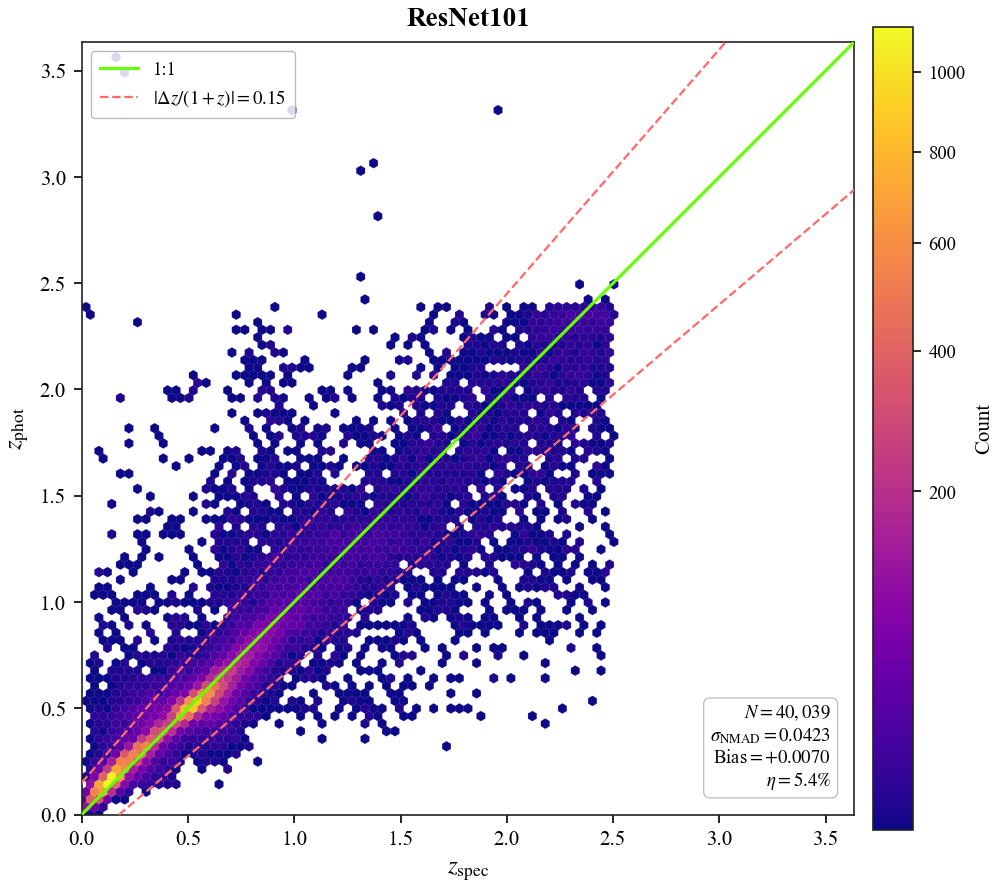

In [32]:
plot_pred_vs_true(
    y_true_primary,
    y_pred_primary,
    name="ResNet101",
    save_path=os.path.join(BASE_REPORTS, "resnet101_scatter.png"),
)

Binned performance saved → /Users/arpinejanunts/Desktop/Capstone/reports/resnet101_binned.png


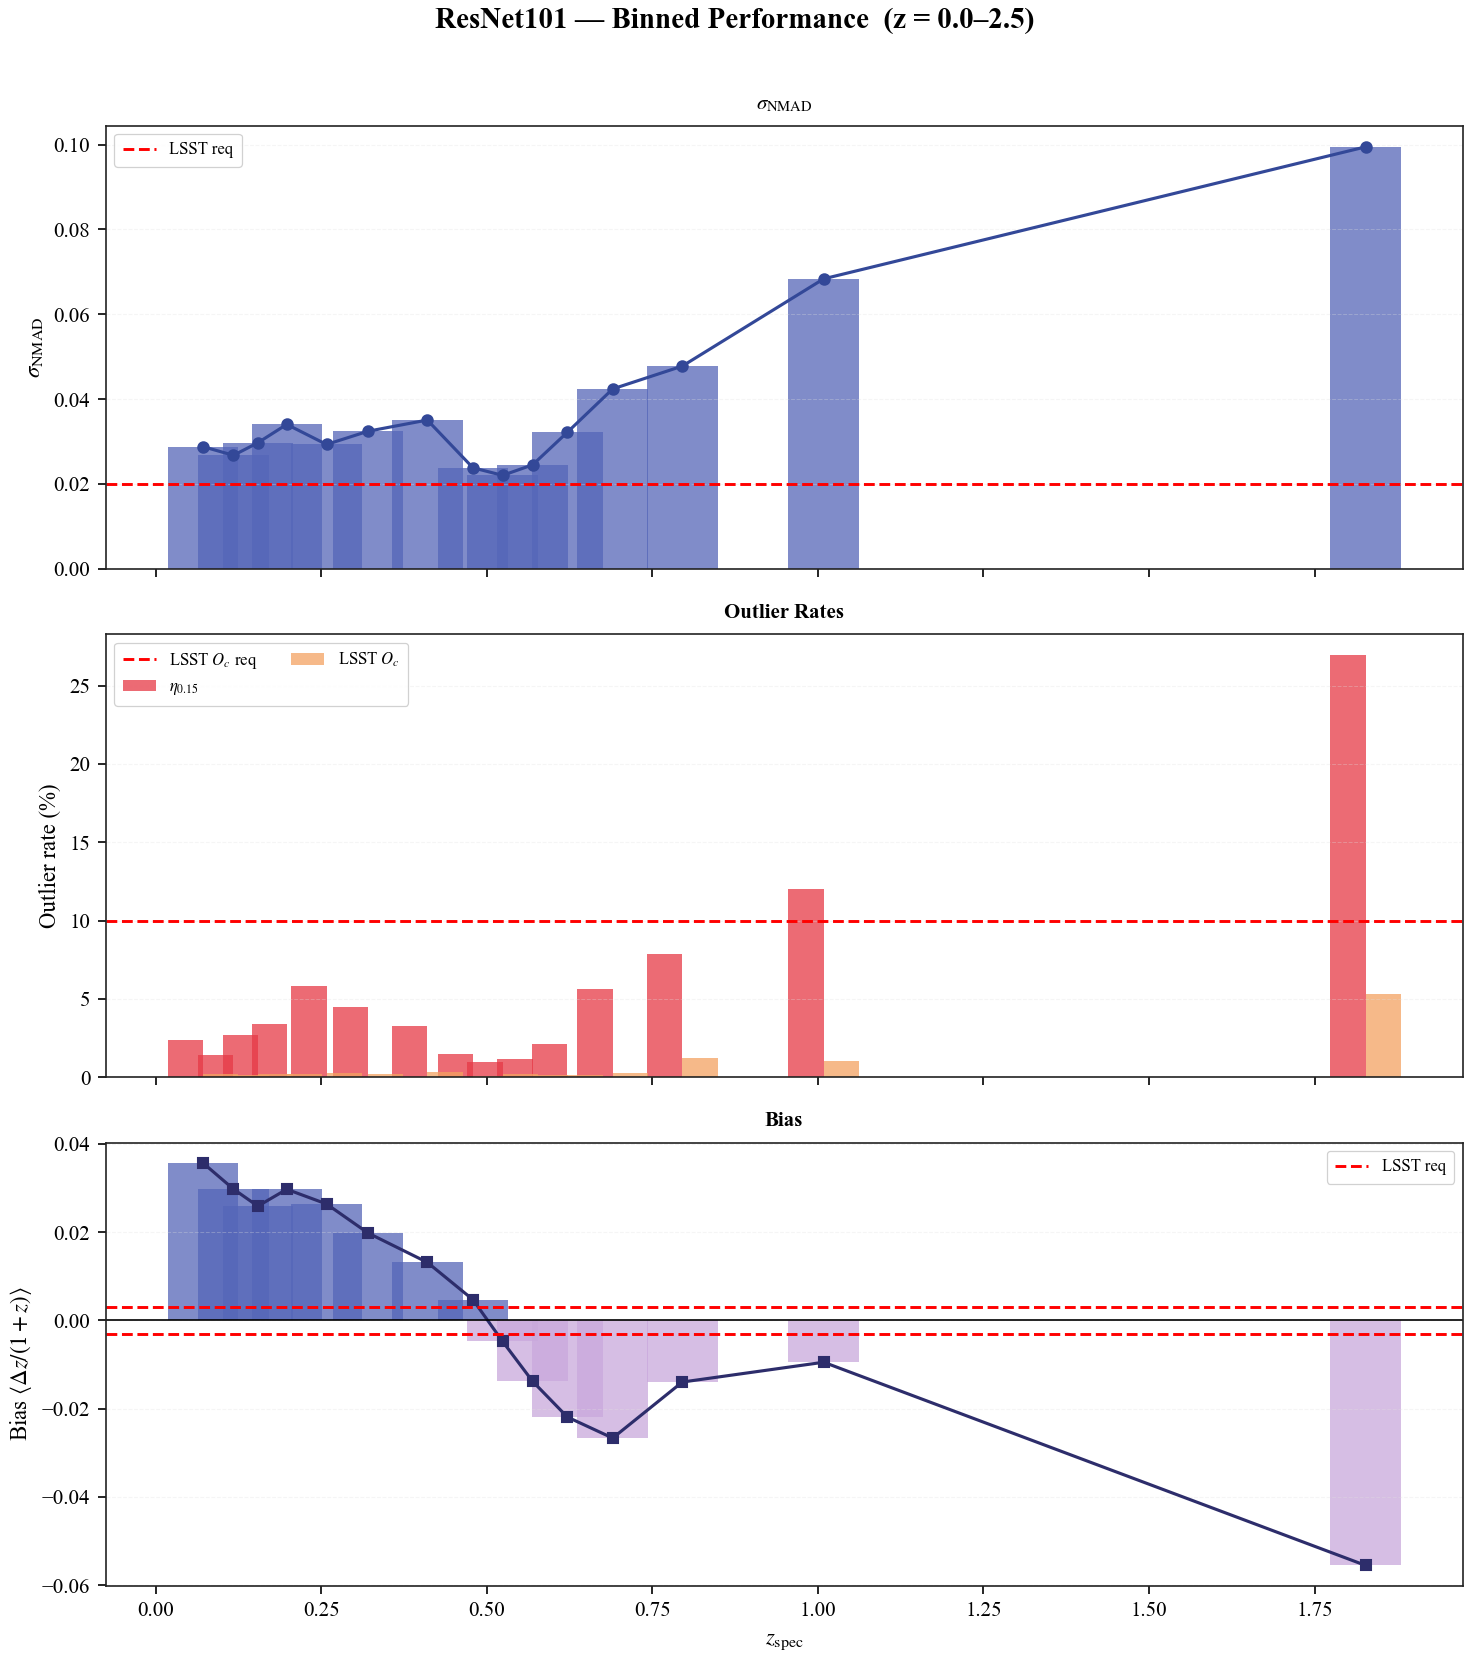

In [33]:
plot_binned_performance(
    y_true_primary,
    y_pred_primary,
    name="ResNet101",
    n_bins=15,
    z_range=(0.0, 2.5),
    save_path=os.path.join(BASE_REPORTS, "resnet101_binned.png"),
)

Figure saved → /Users/arpinejanunts/Desktop/Capstone/reports/resnet101_full_eval.png


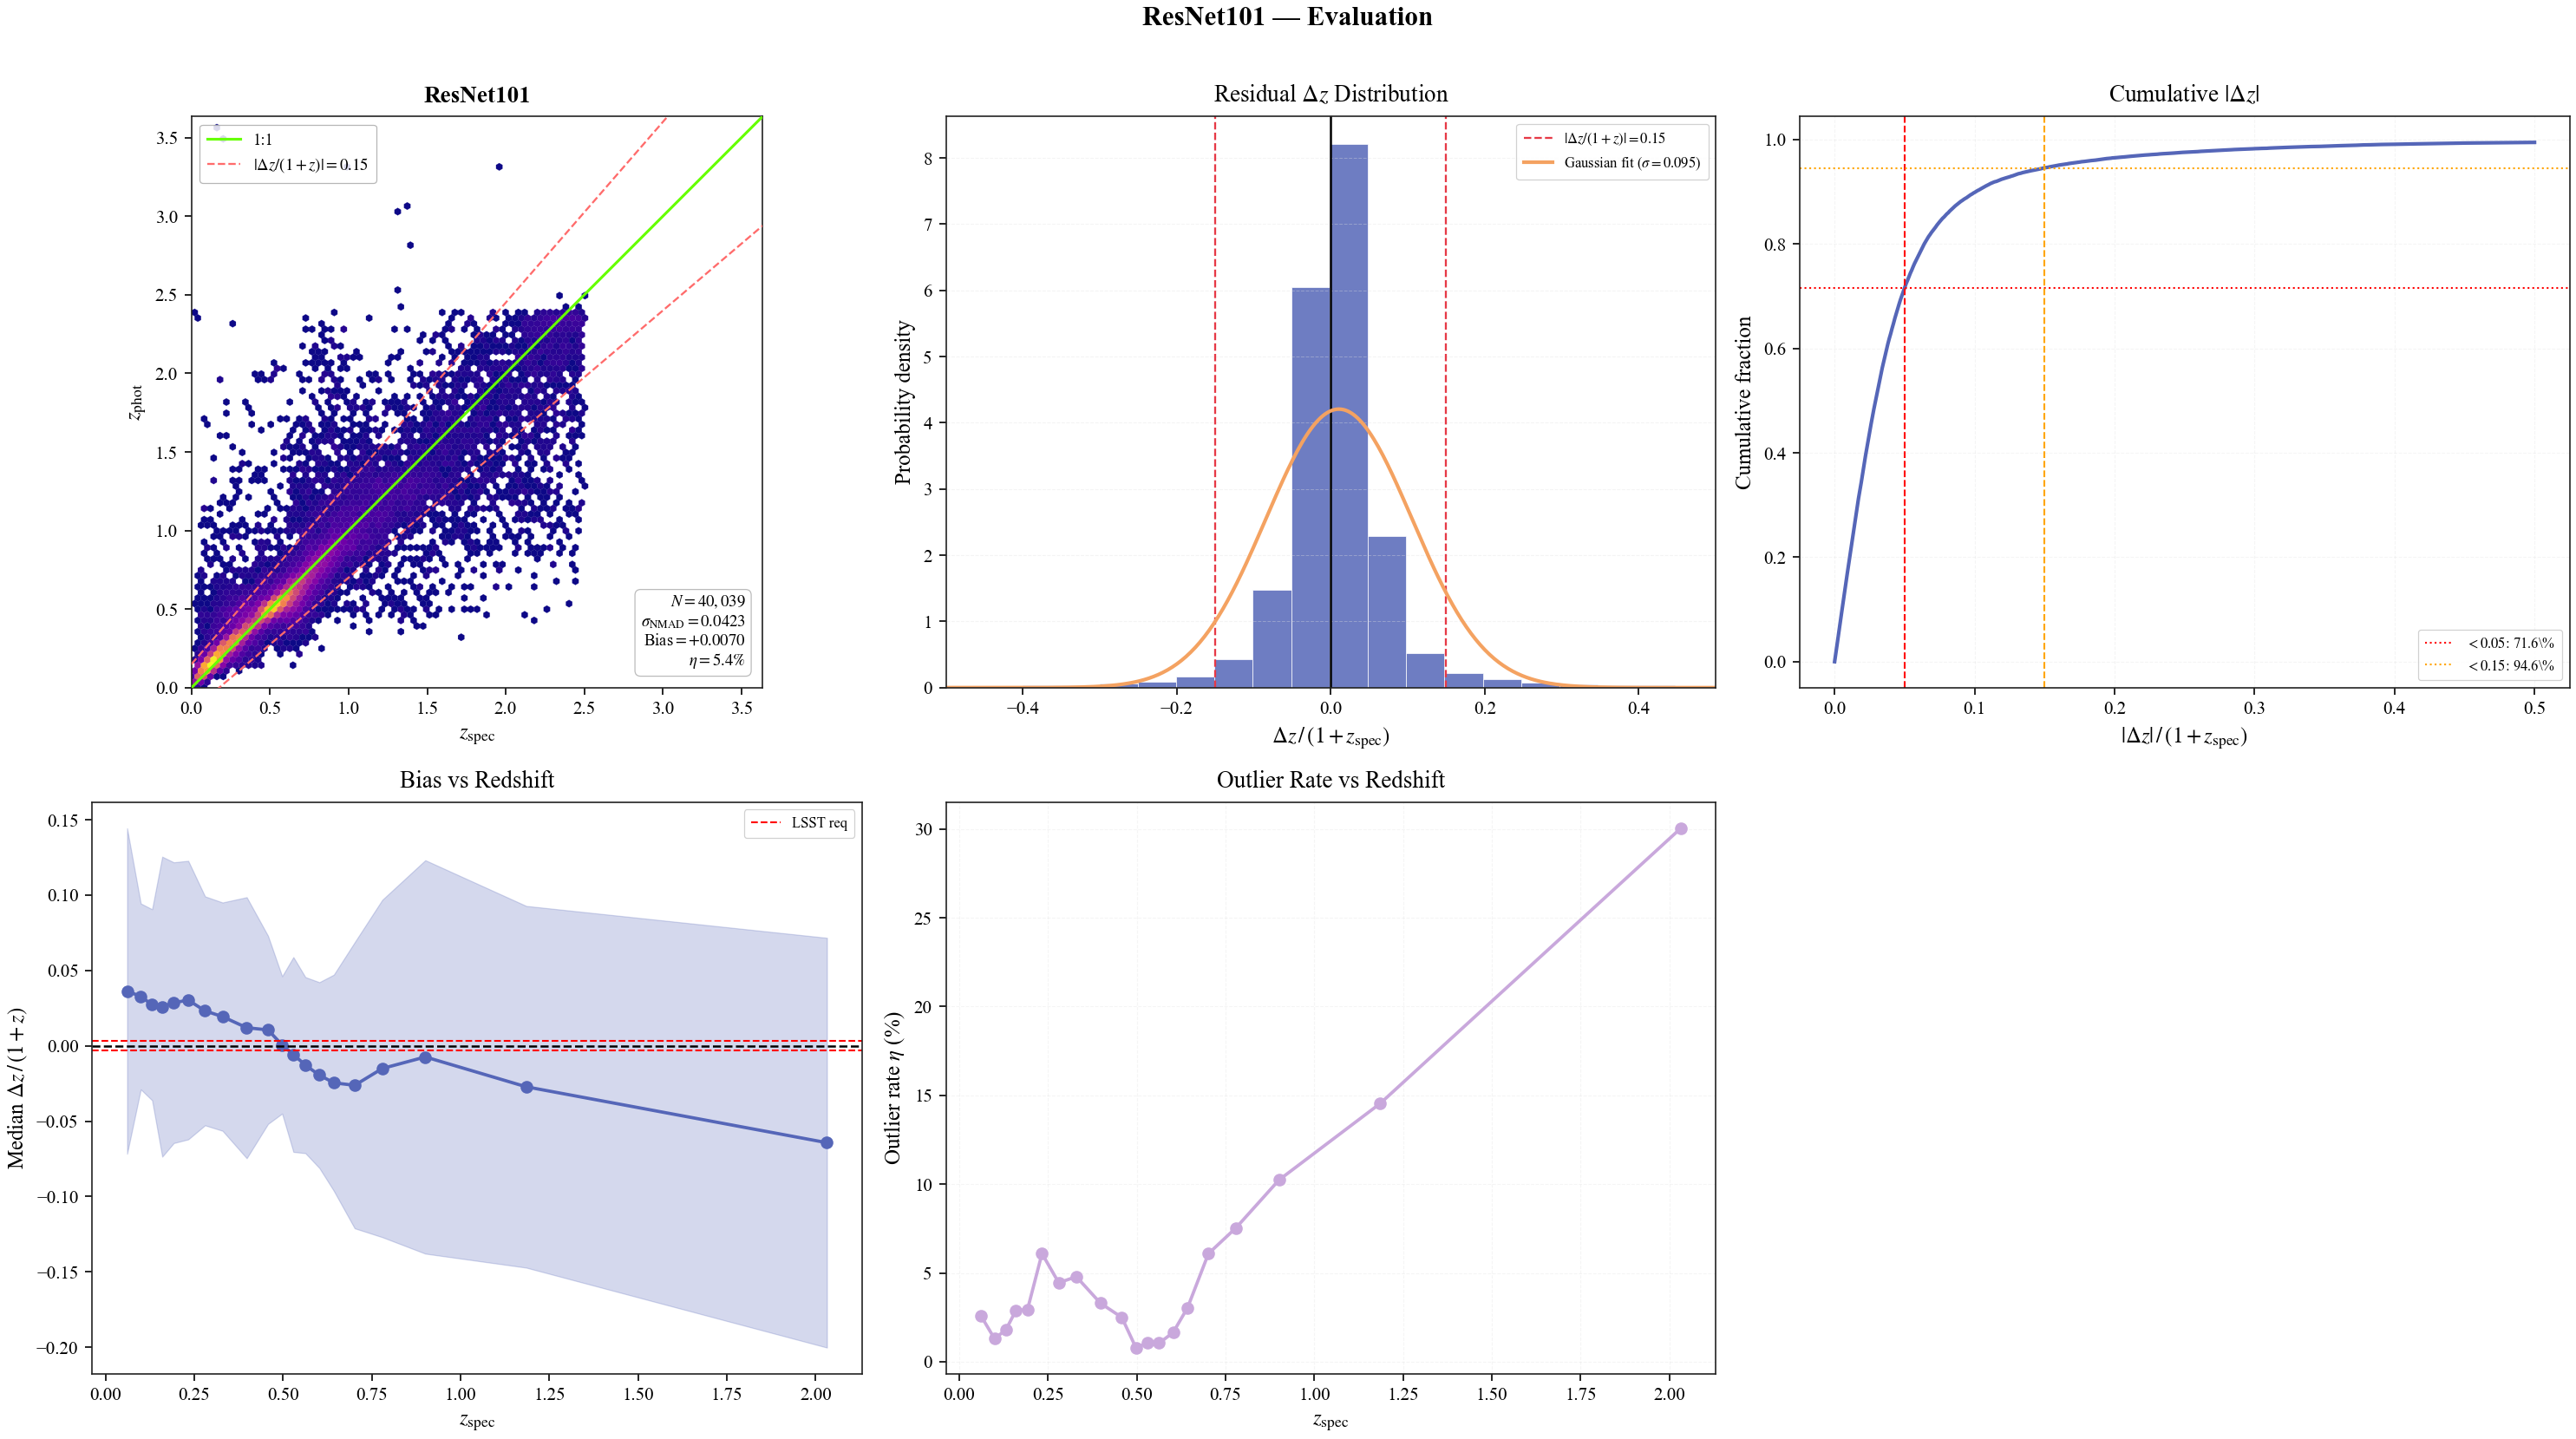

In [34]:
full_evaluation(
    name="ResNet101",
    y_true=y_true_primary,
    y_pred=y_pred_primary,
    save_path=os.path.join(BASE_REPORTS, "resnet101_full_eval.png"),
)